#  MobileNetV2 — Stringing Defect Detection

This notebook trains a **MobileNetV2** transfer-learning model to classify surface images as **Stringing** or **No Stringing**.

| Step | Description |
|------|-------------|
| 1 | Load & preprocess data |
| 2 | Build the model |
| 3 | Compile |
| 4 | Train |
| 5 | Evaluate |
| 6 | Save |

---
##  Imports & Configuration

In [ ]:
print(5)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

2026-05-10 23:56:39.132195: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778453799.231526  193294 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778453799.257924  193294 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-10 23:56:39.412508: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.18.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Step 1 — Load and Preprocess Data

* Point to `data/` folder (contains `Stringing/` and `No_Stringing/` sub-folders)
* Resize all images to **224 × 224**
* Normalize pixels to **[0, 1]**
* Split: **80 % train / 10 % validation / 10 % test**
* Apply **augmentation on training set only** (rotation, flip, brightness)
* Batch size = **32**

In [3]:
# ---------- paths ----------
DATA_DIR = os.path.join(os.getcwd(), "..", "data")

# ---------- constants ----------
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# ---------- collect all file paths + labels ----------
import glob, random

stringing_files   = sorted(glob.glob(os.path.join(DATA_DIR, "Stringing", "*.jpg")))
no_stringing_files = sorted(glob.glob(os.path.join(DATA_DIR, "No_Stringing", "*.jpg")))

print(f"Stringing images    : {len(stringing_files)}")
print(f"No_Stringing images : {len(no_stringing_files)}")

# Label: Stringing = 1, No_Stringing = 0
all_files  = stringing_files + no_stringing_files
all_labels = [1] * len(stringing_files) + [0] * len(no_stringing_files)

# Shuffle together
combined = list(zip(all_files, all_labels))
random.seed(SEED)
random.shuffle(combined)
all_files, all_labels = zip(*combined)
all_files  = list(all_files)
all_labels = list(all_labels)

total = len(all_files)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_files, train_labels = all_files[:train_end],       all_labels[:train_end]
val_files,   val_labels   = all_files[train_end:val_end], all_labels[train_end:val_end]
test_files,  test_labels  = all_files[val_end:],          all_labels[val_end:]

print(f"\nTrain : {len(train_files)}")
print(f"Val   : {len(val_files)}")
print(f"Test  : {len(test_files)}")

Stringing images    : 2555
No_Stringing images : 1811

Train : 3492
Val   : 437
Test  : 437


### 1.1 — Build `tf.data` pipelines with augmentation

In [4]:
def load_and_preprocess(file_path, label):
    """Read an image file, decode, resize, and normalise to [0,1]."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label


def augment(img, label):
    """Apply data-augmentation (training set only)."""
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    # Random rotation (up to 20 degrees ≈ 0.35 rad)
    # tf.image doesn't have random_rotation, so we use keras layer below
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Augmentation layer for rotation ---
rotation_layer = layers.RandomRotation(factor=0.06, seed=SEED)  # ~20°

def augment_with_rotation(img, label):
    img = rotation_layer(img, training=True)
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.2)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label


# --- Datasets ---
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_labels))
    .shuffle(len(train_files), seed=SEED)
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .map(augment_with_rotation, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("✅ Data pipelines ready.")

I0000 00:00:1778453809.481737  193294 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6100 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


✅ Data pipelines ready.


### 1.2 — Visualise a batch of training images

In [ ]:
class_names = ["No_Stringing", "Stringing"]

2026-04-24 14:36:46.761608: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


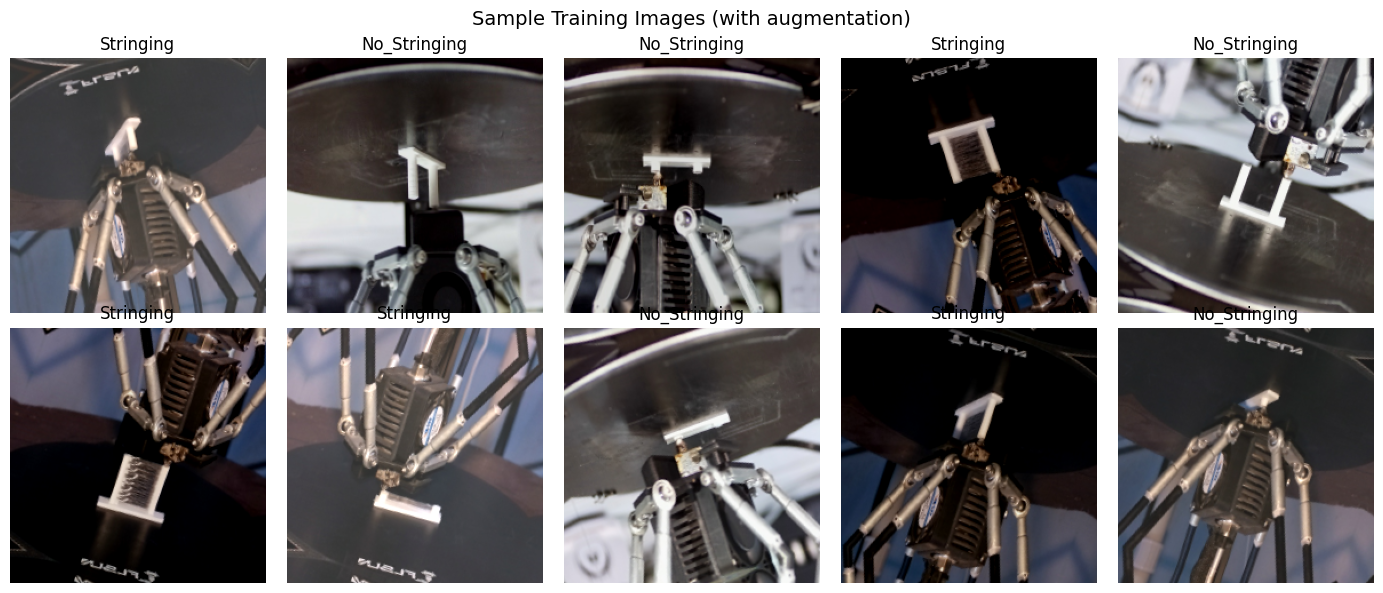

In [4]:
class_names = ["No_Stringing", "Stringing"]

plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(10, len(images))):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.suptitle("Sample Training Images (with augmentation)", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 2 — Build the Model

* Load **MobileNetV2** pretrained on ImageNet (`include_top=False`)
* **Freeze** all base layers
* Add: `GlobalAveragePooling2D → Dense(256, relu) → Dropout(0.3) → Dense(1, sigmoid)`

In [5]:
# ---------- Load pretrained base ----------
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze all base layers
base_model.trainable = False

print(f"Base model layers : {len(base_model.layers)}")
print(f"Trainable weights : {len(base_model.trainable_weights)}")

# ---------- Build classification head ----------
inputs = keras.Input(shape=(224, 224, 3), name="input_image")
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3, name="dropout_03")(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = keras.Model(inputs, outputs, name="MobileNetV2_Stringing")
model.summary()

Base model layers : 154
Trainable weights : 0


Model: "MobileNetV2_Stringing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

---
## Step 3 — Compile

* Optimizer: **Adam** (lr = 0.0001)
* Loss: **binary_crossentropy**
* Metrics: **accuracy**

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print("✅ Model compiled.")

✅ Model compiled.


---
## Step 4 — Train

* Epochs: **50**
* Callbacks:
  * `EarlyStopping` — patience = 10, monitor `val_loss`
  * `ReduceLROnPlateau` — factor 0.5, patience 5
  * `ModelCheckpoint` — save best model

In [7]:
EPOCHS = 50
BEST_MODEL_PATH = "best_mobilenetv2_stringing.h5"

cb_list = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb_list,
)

print("\n✅ Training complete.")

Epoch 1/50


I0000 00:00:1777037823.194182   29007 service.cc:148] XLA service 0x747b400017a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777037823.194235   29007 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-04-24 14:37:03.338335: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777037824.005839   29007 cuda_dnn.cc:529] Loaded cuDNN version 90300


  5/110 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.3300 - loss: 0.9950 

I0000 00:00:1777037828.769435   29007 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.5817 - loss: 0.7165
Epoch 1: val_loss improved from None to 0.50915, saving model to best_mobilenetv2_stringing.h5


...


Epoch 37: finished saving model to best_mobilenetv2_stringing.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ -7s -64621us/step - accuracy: 0.9198 - loss: 0.1843 - val_accuracy: 0.9108 - val_loss: 0.1983 - learning_rate: 1.0000e-04
Epoch 38/50
 62/110 ━━━━━━━━━━━━━━━━━━━━ 11s 240ms/step - accuracy: 0.9258 - loss: 0.1711
Epoch 38: val_loss did not improve from 0.19830
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9296 - loss: 0.1737 - val_accuracy: 0.9085 - val_loss: 0.2060 - learning_rate: 1.0000e-04
Epoch 39/50
 64/110 ━━━━━━━━━━━━━━━━━━━━ 10s 232ms/step - accuracy: 0.9366 - loss: 0.1665
Epoch 39: val_loss did not improve from 0.19830
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9290 - loss: 0.1763 - val_accuracy: 0.9199 - val_loss: 0.2028 - learning_rate: 1.0000e-04
Epoch 40/50
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9334 - loss: 0.1709
Epoch 40: val_loss did not improve from 0.19830
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step - accuracy: 0.9361 - loss: 0.1647 


Epoch 42: finished saving model to best_mobilenetv2_stringing.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9356 - loss: 0.1624 - val_accuracy: 0.9199 - val_loss: 0.1945 - learning_rate: 1.0000e-04
Epoch 43/50
 71/110 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9338 - loss: 0.1702
Epoch 43: val_loss did not improve from 0.19446
110/110 ━━━━━━━━━━━━━━━━━━━━ -7s -67317us/step - accuracy: 0.9367 - loss: 0.1603 - val_accuracy: 0.8924 - val_loss: 0.2207 - learning_rate: 1.0000e-04
Epoch 44/50
 72/110 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - accuracy: 0.9278 - loss: 0.1736
Epoch 44: val_loss improved from 0.19446 to 0.18757, saving model to best_mobilenetv2_stringing.h5



Epoch 44: finished saving model to best_mobilenetv2_stringing.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.9316 - loss: 0.1661 - val_accuracy: 0.9222 - val_loss: 0.1876 - learning_rate: 1.0000e-04
Epoch 45/50
 65/110 ━━━━━━━━━━━━━━━━━━━━ 10s 228ms/step - accuracy: 0.9376 - loss: 0.1563
Epoch 45: val_loss did not improve from 0.18757
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9413 - loss: 0.1548 - val_accuracy: 0.8993 - val_loss: 0.1954 - learning_rate: 1.0000e-04
Epoch 46/50
 73/110 ━━━━━━━━━━━━━━━━━━━━ 7s 207ms/step - accuracy: 0.9280 - loss: 0.1650
Epoch 46: val_loss did not improve from 0.18757
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9361 - loss: 0.1607 - val_accuracy: 0.9222 - val_loss: 0.1922 - learning_rate: 1.0000e-04
Epoch 47/50
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - accuracy: 0.9398 - loss: 0.1560
Epoch 47: val_loss improved from 0.18757 to 0.18282, saving model to best_mobilenetv2_stringing.h5



Epoch 47: finished saving model to best_mobilenetv2_stringing.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 17s 158ms/step - accuracy: 0.9373 - loss: 0.1539 - val_accuracy: 0.9199 - val_loss: 0.1828 - learning_rate: 1.0000e-04
Epoch 48/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9352 - loss: 0.1643
Epoch 48: val_loss did not improve from 0.18282
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9307 - loss: 0.1682 - val_accuracy: 0.9153 - val_loss: 0.1889 - learning_rate: 1.0000e-04
Epoch 49/50
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9418 - loss: 0.1516
Epoch 49: val_loss did not improve from 0.18282
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.9379 - loss: 0.1553 - val_accuracy: 0.9176 - val_loss: 0.2048 - learning_rate: 1.0000e-04
Epoch 50/50
 85/110 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9313 - loss: 0.1584
Epoch 50: val_loss improved from 0.18282 to 0.17749, saving model to best_mobilenetv2_stringing.h5



Epoch 50: finished saving model to best_mobilenetv2_stringing.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ -7s -66437us/step - accuracy: 0.9347 - loss: 0.1583 - val_accuracy: 0.9222 - val_loss: 0.1775 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 50.

✅ Training complete.


---
## Step 5 — Evaluate

* Load best saved model
* Run on test set
* Print: **accuracy, precision, recall, F1-score**
* Plot: **confusion matrix, ROC curve, training/validation accuracy & loss curves**

### 5.1 — Load best model & predict on test set

In [8]:
# Load best checkpoint
best_model = keras.models.load_model(BEST_MODEL_PATH)

# Predict
y_pred_probs = best_model.predict(test_ds).ravel()
y_pred = (y_pred_probs >= 0.5).astype(int)
y_true = np.array(test_labels)

print(f"Test samples : {len(y_true)}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 238ms/step
Test samples : 437


### 5.2 — Classification metrics

In [9]:
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print("="*50)
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print("="*50)
print()
print(classification_report(y_true, y_pred, target_names=class_names))

  Accuracy  : 0.9314
  Precision : 0.9259
  Recall    : 0.9615
  F1-Score  : 0.9434

              precision    recall  f1-score   support

No_Stringing       0.94      0.89      0.91       177
   Stringing       0.93      0.96      0.94       260

    accuracy                           0.93       437
   macro avg       0.93      0.92      0.93       437
weighted avg       0.93      0.93      0.93       437



### 5.3 — Confusion Matrix

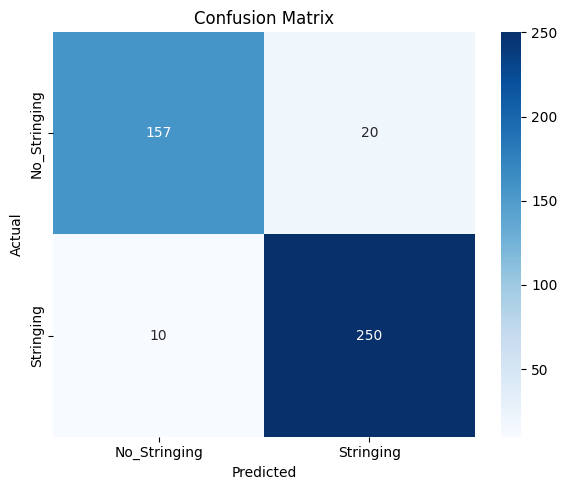

In [10]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### 5.4 — ROC Curve

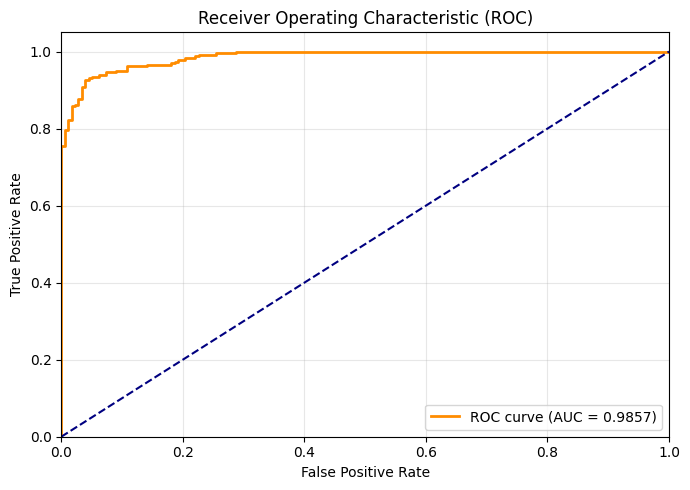

In [11]:
fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Training / Validation Accuracy & Loss Curves

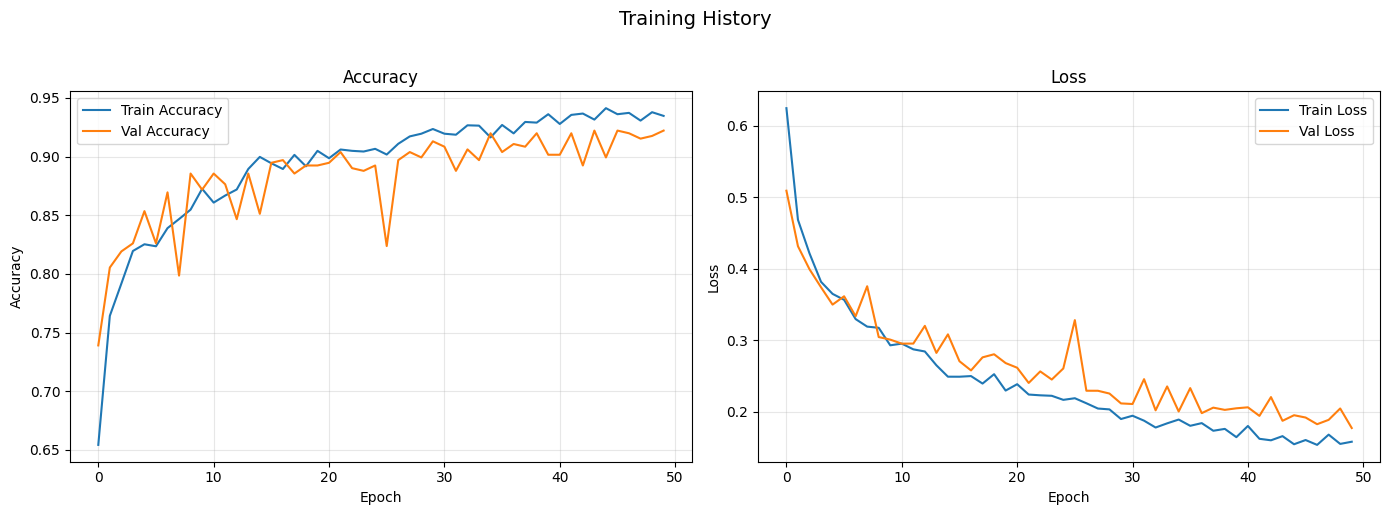

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history["accuracy"],    label="Train Accuracy")
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history["loss"],     label="Train Loss")
axes[1].plot(history.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
## Step 6 — Save the Model

* Save as **`.h5`** (Keras format)
* Save as **`SavedModel`** format (for later TFLite conversion)

In [13]:
# 1) Save as .h5
H5_PATH = "mobilenetv2_stringing_final.h5"
best_model.save(H5_PATH)
print(f"✅ Model saved as HDF5       → {H5_PATH}")

# 2) Save as SavedModel directory
SAVED_MODEL_DIR = "mobilenetv2_stringing_savedmodel"
best_model.save(SAVED_MODEL_DIR)
print(f"✅ Model saved as SavedModel → {SAVED_MODEL_DIR}/")

✅ Model saved as HDF5       → mobilenetv2_stringing_final.h5


ValueError: Invalid filepath extension for saving. Please add either a `.keras` extension for the native Keras format (recommended) or a `.h5` extension. Use `model.export(filepath)` if you want to export a SavedModel for use with TFLite/TFServing/etc. Received: filepath=mobilenetv2_stringing_savedmodel.

---
### ✅ Done!

The trained MobileNetV2 model for **Stringing vs No_Stringing** detection is now saved and ready for deployment or TFLite conversion.

---
## Round 1 — Fine-Tuning: Unfreeze Last 20 Layers

The base model was fully frozen during the first training phase (only the custom head was trained).  
Here we apply **fine-tuning** by selectively unfreezing the **last 20 layers** of MobileNetV2 and training with a very low learning rate.

| Hyperparameter | Phase 1 (original) | Phase 2 (fine-tuning) |
|----------------|--------------------|-----------------------|
| Base model layers | **All frozen** (0 trainable) | **Last 20 unfrozen** |
| Learning rate | 0.0001 (1e-4) | **0.00001 (1e-5)** |
| Loss | binary_crossentropy | binary_crossentropy |
| Batch size | 32 | 32 |
| Max epochs | 50 | 50 |
| Callbacks | EarlyStopping / ReduceLR / Checkpoint | same |
| Data | same train/val/test splits | same |

> **Why 1e-5?** Fine-tuning requires a much smaller LR than initial training (10× lower here)  
> to avoid destroying the pre-learned ImageNet features in the unfrozen layers.

### Step 1 — Load the best model from Phase 1

In [6]:
# Load the best checkpoint saved during Phase 1
ft_model = keras.models.load_model("best_mobilenetv2_stringing.h5")
print("✅ Phase-1 best model loaded.")

✅ Phase-1 best model loaded.


### Step 2 — Unfreeze the last 20 layers of the MobileNetV2 base

We target only the top of the base model (high-level, task-specific features).  
The early layers (low-level edge/texture detectors) stay frozen to preserve ImageNet weights.

In [7]:
# Locate the MobileNetV2 base inside the loaded model
base_model = ft_model.get_layer("mobilenetv2_1.00_224")

# Keep all base layers frozen first, then selectively unfreeze the last 20
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Summary of trainable status
total   = len(base_model.layers)
frozen  = sum(not l.trainable for l in base_model.layers)
unfrozen = sum(l.trainable for l in base_model.layers)
print(f"Base model total layers : {total}")
print(f"  Frozen                : {frozen}")
print(f"  Unfrozen (last 20)    : {unfrozen}")
print()
ft_model.summary()

Base model total layers : 154
  Frozen                : 134
  Unfrozen (last 20)    : 20



Model: "MobileNetV2_Stringing"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_03 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,179 (9.87 MB)

 Trainable params: 1,534,273 (5.85 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

 Optimizer params: 2 (12.00 B)

### Step 3 — Recompile with a 10× lower learning rate

A very low LR (`1e-5`) lets the unfrozen weights adapt gently to the stringing task  
without catastrophically forgetting the ImageNet features.

In [8]:
FT_LR = 1e-5   # 10× lower than original 1e-4

ft_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FT_LR),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

print(f"✅ Model recompiled — learning rate = {FT_LR}")

✅ Model recompiled — learning rate = 1e-05


### Step 4 — Callbacks (same as Phase 1) & Train

The best fine-tuned model is saved to a **new file** so Phase 1 weights are not overwritten.

In [ ]:
FT_BEST_MODEL_PATH = "best_mobilenetv2_stringing_finetuned.h5"

In [9]:
FT_EPOCHS = 50
FT_BEST_MODEL_PATH = "best_mobilenetv2_stringing_finetuned.h5"

ft_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1,
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=FT_BEST_MODEL_PATH,
        monitor="val_loss",
        save_best_only=True,
        verbose=1,
    ),
]

# Fine-tune on the same train_ds / val_ds used in Phase 1
ft_history = ft_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FT_EPOCHS,
    callbacks=ft_callbacks,
)

print("\n✅ Fine-tuning complete.")

Epoch 1/50


I0000 00:00:1778454002.799525  193794 service.cc:148] XLA service 0x744d68010290 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778454002.799649  193794 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 2060 SUPER, Compute Capability 7.5
2026-05-11 00:00:03.081416: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778454004.025113  193794 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/110 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.6953 - loss: 0.6410  

I0000 00:00:1778454010.604939  193794 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8032 - loss: 0.4523

...


Epoch 36: finished saving model to best_mobilenetv2_stringing_finetuned.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9737 - loss: 0.0642 - val_accuracy: 0.9634 - val_loss: 0.0804 - learning_rate: 2.5000e-06
Epoch 37/50
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.9757 - loss: 0.0614
Epoch 37: val_loss improved from 0.08044 to 0.07758, saving model to best_mobilenetv2_stringing_finetuned.h5



Epoch 37: finished saving model to best_mobilenetv2_stringing_finetuned.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.9754 - loss: 0.0618 - val_accuracy: 0.9657 - val_loss: 0.0776 - learning_rate: 2.5000e-06
Epoch 38/50
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9792 - loss: 0.0609
Epoch 38: val_loss did not improve from 0.07758
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.9774 - loss: 0.0641 - val_accuracy: 0.9634 - val_loss: 0.0871 - learning_rate: 2.5000e-06
Epoch 39/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9747 - loss: 0.0596
Epoch 39: val_loss did not improve from 0.07758
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9759 - loss: 0.0616 - val_accuracy: 0.9634 - val_loss: 0.0855 - learning_rate: 2.5000e-06
Epoch 40/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9761 - loss: 0.0577
Epoch 40: val_loss did not improve from 0.07758
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.9762 - loss: 0.0604 -


Epoch 42: finished saving model to best_mobilenetv2_stringing_finetuned.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.9785 - loss: 0.0590 - val_accuracy: 0.9634 - val_loss: 0.0721 - learning_rate: 2.5000e-06
Epoch 43/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9785 - loss: 0.0499
Epoch 43: val_loss did not improve from 0.07206
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9765 - loss: 0.0558 - val_accuracy: 0.9588 - val_loss: 0.0722 - learning_rate: 2.5000e-06
Epoch 44/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9805 - loss: 0.0528
Epoch 44: val_loss did not improve from 0.07206
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9762 - loss: 0.0596 - val_accuracy: 0.9680 - val_loss: 0.0722 - learning_rate: 2.5000e-06
Epoch 45/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9802 - loss: 0.0596
Epoch 45: val_loss improved from 0.07206 to 0.06740, saving model to best_mobilenetv2_stringing_finetuned.h5



Epoch 45: finished saving model to best_mobilenetv2_stringing_finetuned.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9779 - loss: 0.0636 - val_accuracy: 0.9703 - val_loss: 0.0674 - learning_rate: 2.5000e-06
Epoch 46/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9787 - loss: 0.0609
Epoch 46: val_loss did not improve from 0.06740
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9777 - loss: 0.0574 - val_accuracy: 0.9634 - val_loss: 0.0696 - learning_rate: 2.5000e-06
Epoch 47/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9752 - loss: 0.0631
Epoch 47: val_loss did not improve from 0.06740
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9739 - loss: 0.0649 - val_accuracy: 0.9634 - val_loss: 0.0709 - learning_rate: 2.5000e-06
Epoch 48/50
108/110 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9809 - loss: 0.0524
Epoch 48: val_loss did not improve from 0.06740
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9814 - loss: 0.0531 - 


Epoch 49: finished saving model to best_mobilenetv2_stringing_finetuned.h5
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.9814 - loss: 0.0526 - val_accuracy: 0.9680 - val_loss: 0.0652 - learning_rate: 2.5000e-06
Epoch 50/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9788 - loss: 0.0542
Epoch 50: val_loss did not improve from 0.06518
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9782 - loss: 0.0553 - val_accuracy: 0.9680 - val_loss: 0.0694 - learning_rate: 2.5000e-06
Restoring model weights from the end of the best epoch: 49.

✅ Fine-tuning complete.


### Step 5 — Evaluate the fine-tuned model on the test set

In [10]:
ft_best = keras.models.load_model(FT_BEST_MODEL_PATH)

ft_y_pred_probs = ft_best.predict(test_ds, verbose=1).ravel()
ft_y_pred       = (ft_y_pred_probs >= 0.5).astype(int)
y_true = np.concatenate([y for _, y in test_ds], axis=0)

ft_acc  = accuracy_score(y_true, ft_y_pred)
ft_prec = precision_score(y_true, ft_y_pred)
ft_rec  = recall_score(y_true, ft_y_pred)
ft_f1   = f1_score(y_true, ft_y_pred)

print("=" * 50)
print(f"  Accuracy  : {ft_acc:.4f}  ({ft_acc*100:.2f}%)")
print(f"  Precision : {ft_prec:.4f}")
print(f"  Recall    : {ft_rec:.4f}")
print(f"  F1-Score  : {ft_f1:.4f}")
print("=" * 50)
print()
print(classification_report(
    y_true, ft_y_pred,
    target_names=["No_stringing", "stringing"]
))

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step
  Accuracy  : 0.9657  (96.57%)
  Precision : 0.9658
  Recall    : 0.9769
  F1-Score  : 0.9713

              precision    recall  f1-score   support

No_stringing       0.97      0.95      0.96       177
   stringing       0.97      0.98      0.97       260

    accuracy                           0.97       437
   macro avg       0.97      0.96      0.96       437
weighted avg       0.97      0.97      0.97       437



2026-05-11 00:04:15.992163: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
cm = confusion_matrix(y_true, ft_y_pred )

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Step 6 — Training History: Phase 1 vs Fine-Tuning

Plot both training runs side-by-side to see whether fine-tuning improved generalization.

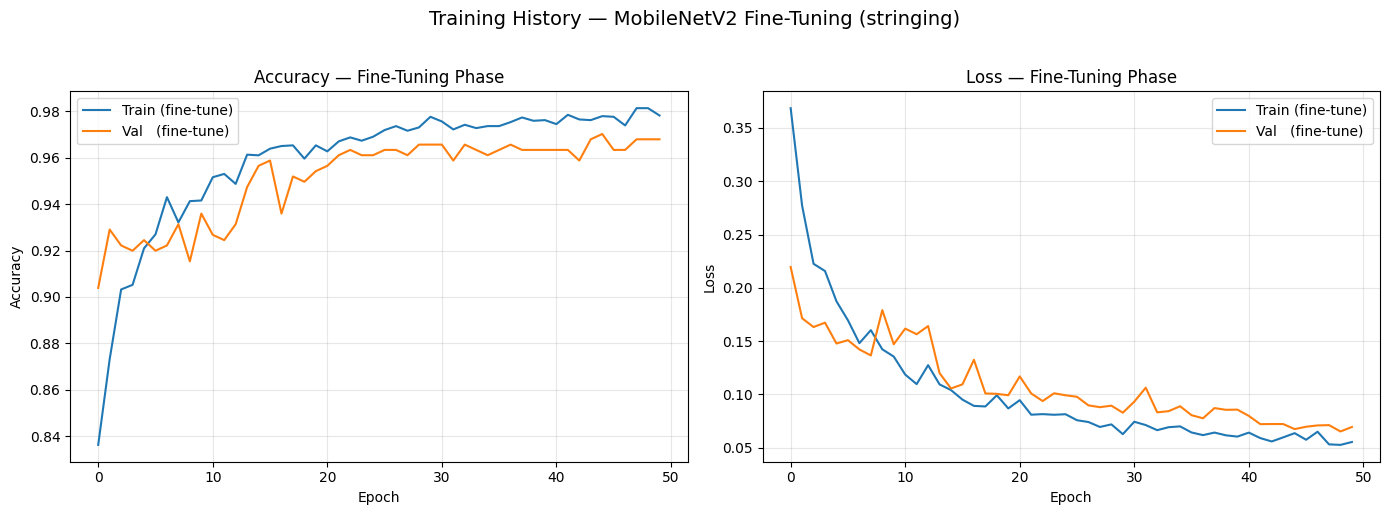

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Accuracy ──
axes[0].plot(ft_history.history["accuracy"],     label="Train (fine-tune)")
axes[0].plot(ft_history.history["val_accuracy"],  label="Val   (fine-tune)")
axes[0].set_title("Accuracy — Fine-Tuning Phase")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Loss ──
axes[1].plot(ft_history.history["loss"],     label="Train (fine-tune)")
axes[1].plot(ft_history.history["val_loss"],  label="Val   (fine-tune)")
axes[1].set_title("Loss — Fine-Tuning Phase")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Training History — MobileNetV2 Fine-Tuning (stringing)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Step 7 — Save the Fine-Tuned Model

In [12]:
FT_FINAL_PATH = "mobilenetv2_stringing_finetuned_final.h5"
ft_best.save(FT_FINAL_PATH)
print(f"✅ Fine-tuned model saved → {FT_FINAL_PATH}")

✅ Fine-tuned model saved → mobilenetv2_stringing_finetuned_final.h5
